<a href="https://colab.research.google.com/github/Vaishnavikavi/covid19-data-analysis/blob/main/covid_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Data Analysis

## Problem Statement

The objective of this project is to perform an exploratory data analysis (EDA) on publicly available COVID-19 data to understand the spread and impact of the pandemic across different countries. The analysis focuses on identifying temporal trends in confirmed cases and deaths, comparing patterns across selected countries, and exploring the relationship between confirmed cases and mortality.


## Dataset Description

The dataset used in this analysis is a country-level aggregated COVID-19 dataset provided by DataHub. It compiles publicly available COVID-19 data from sources including the Johns Hopkins University Center for Systems Science and Engineering (CSSE). The dataset contains daily records of confirmed cases, deaths, and recoveries for multiple countries over time.

Key columns in the dataset include:
- Date: The reporting date
- Country: Name of the country
- Confirmed: Total number of confirmed COVID-19 cases
- Deaths: Total number of deaths
- Recovered: Total number of recoveries


In [65]:
import pandas as pd


In [66]:
url = "https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv"
df = pd.read_csv(url)


## Data Cleaning and Preparation
This section inspects the dataset for missing values and corrects data types. It also filters the dataset to include only selected countries for further analysis.


In [67]:
# Inspect dataset
df.head()
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161568 entries, 0 to 161567
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Date       161568 non-null  object
 1   Country    161568 non-null  object
 2   Confirmed  161568 non-null  int64 
 3   Recovered  161568 non-null  int64 
 4   Deaths     161568 non-null  int64 
dtypes: int64(3), object(2)
memory usage: 6.2+ MB


,0
Date,0
Country,0
Confirmed,0
Recovered,0
Deaths,0


In [68]:
# Data type correction
df['Date'] = pd.to_datetime(df['Date'])

In [69]:
# Filter selected countries
countries = ['India', 'Germany', 'US']
df_filtered = df[df['Country'].isin(countries)]


In [70]:
# Verify country labels
df['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antarctica', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia',
       'Comoros', 'Congo (Brazzaville)', 'Congo (Kinshasa)', 'Costa Rica',
       "Cote d'Ivoire", 'Croatia', 'Cuba', 'Cyprus', 'Czechia', 'Denmark',
       'Diamond Princess', 'Djibouti', 'Dominica', 'Dominican Republic',
       'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea',
       'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece',
       'Grenada', 'Gua

## Exploratory Data Analysis

This section explores trends, comparisons, and relationships within the COVID-19 dataset using visual analysis.


### Death Trends Over Time


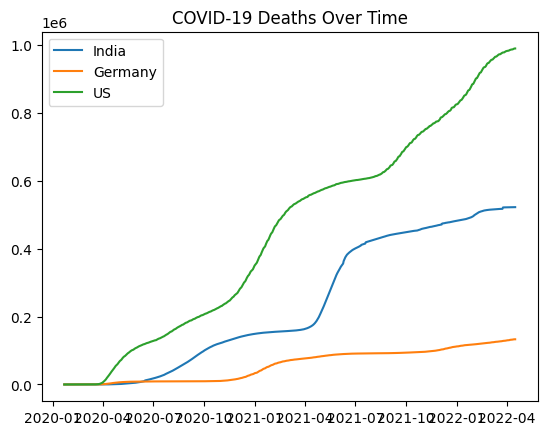

In [71]:
for country in countries:
    country_data = df_filtered[df_filtered['Country'] == country]
    plt.plot(country_data['Date'], country_data['Deaths'], label=country)

plt.legend()
plt.title("COVID-19 Deaths Over Time")
plt.show()

The death trends follow patterns similar to confirmed cases, with higher mortality observed in countries reporting larger case counts.

### Confirmed Cases Over Time



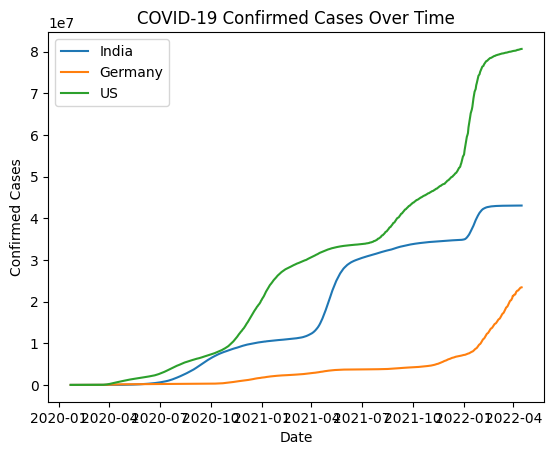

In [72]:
import matplotlib.pyplot as plt

for country in countries:
    country_data = df_filtered[df_filtered['Country'] == country]
    plt.plot(country_data['Date'], country_data['Confirmed'], label=country)

plt.legend()
plt.title("COVID-19 Confirmed Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.show()

This plot shows the trend of confirmed COVID-19 cases over time for selected countries. The United States exhibits the steepest increase, while Germany shows comparatively slower growth.


### Deaths vs Confirmed Cases


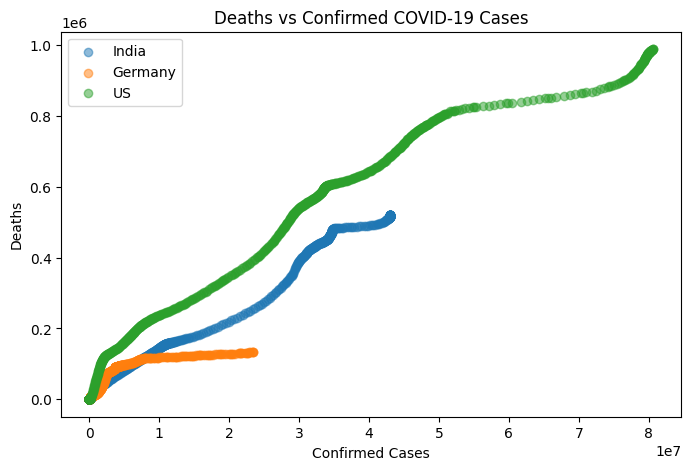

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for country in countries:
    country_data = df_filtered[df_filtered['Country'] == country]
    plt.scatter(
        country_data['Confirmed'],
        country_data['Deaths'],
        label=country,
        alpha=0.5
    )

plt.legend()
plt.title("Deaths vs Confirmed COVID-19 Cases")
plt.xlabel("Confirmed Cases")
plt.ylabel("Deaths")
plt.show()

A positive relationship is observed between confirmed cases and deaths, indicating that higher infection counts are associated with increased mortality.


### Top 5 Countries by Confirmed Cases



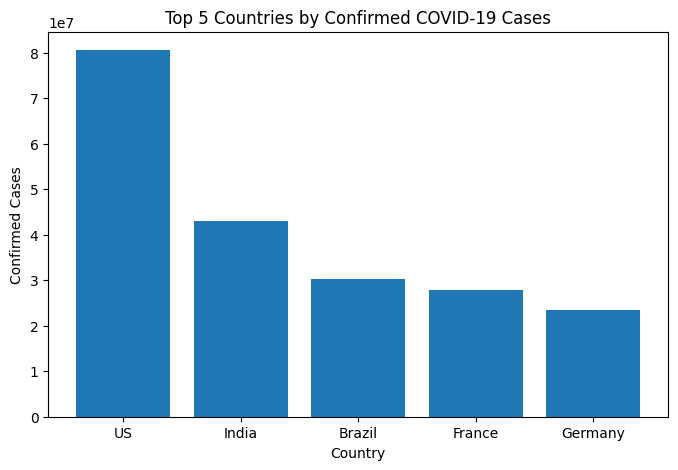

In [74]:
latest_date = df['Date'].max()

latest_data = df[df['Date'] == latest_date]

top5 = latest_data.sort_values(
    by='Confirmed',
    ascending=False
).head(5)

plt.figure(figsize=(8,5))
plt.bar(top5['Country'], top5['Confirmed'])
plt.title("Top 5 Countries by Confirmed COVID-19 Cases")
plt.xlabel("Country")
plt.ylabel("Confirmed Cases")
plt.show()

This bar chart highlights that a small number of countries account for a disproportionately large share of global confirmed COVID-19 cases.

## Key Insights

- The United States experienced the highest number of confirmed COVID-19 cases among the selected countries, showing a steep upward trend.
- India exhibited a delayed but rapid increase in confirmed cases over time.
- Germany showed comparatively lower case and death counts, indicating differences in outbreak severity and response.
- A strong positive relationship is observed between confirmed cases and deaths across all countries analyzed.
- A small number of countries contribute disproportionately to the total number of global confirmed cases.





## Conclusion

This exploratory data analysis demonstrates how publicly available healthcare data can be used to identify temporal trends, inter-country differences, and relationships between key epidemiological variables. The analysis highlights significant variation in COVID-19 case growth and mortality across countries, emphasizing the importance of data-driven insights in public health decision-making.
